In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

#load the csv file
df = pd.read_csv("C:/Users/choic/Downloads/Extension_Dry_1_20mmmin_C.csv")
print(df)

     Record Strain (%) Stress (MPa)
0    Record   % Strain          MPa
1         1        0.0          0.3
2         1        0.0          0.1
3         1        0.0          0.1
4         1        0.0          0.1
..      ...        ...          ...
107       1        3.6          1.0
108       1        3.7          1.2
109       1        3.8          1.6
110       1        3.9          1.4
111       1        3.9          1.3

[112 rows x 3 columns]


In [40]:
#Remove the repeated header row
df = df[df['Strain (%)'] != 'Strain']

#Convert columns to numbers
df["Strain (%)"] = pd.to_numeric(df["Strain (%)"], errors='coerce')
df["Stress (MPa)"] = pd.to_numeric(df["Stress (MPa)"], errors='coerce')
df = df.dropna(subset=["Strain (%)", "Stress (MPa)"])  # Drop rows with NaN values in these columns

#Sort by strain
df = df.sort_values("Strain (%)")

#Check the data
print(df.head())
print(df.info())

  Record  Strain (%)  Stress (MPa)
1      1         0.0           0.3
2      1         0.0           0.1
3      1         0.0           0.1
4      1         0.0           0.1
5      1         0.0           0.3
<class 'pandas.core.frame.DataFrame'>
Index: 111 entries, 1 to 111
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Record        111 non-null    object 
 1   Strain (%)    111 non-null    float64
 2   Stress (MPa)  111 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.5+ KB
None


In [41]:
print(df)

    Record  Strain (%)  Stress (MPa)
1        1         0.0           0.3
2        1         0.0           0.1
3        1         0.0           0.1
4        1         0.0           0.1
5        1         0.0           0.3
..     ...         ...           ...
107      1         3.6           1.0
108      1         3.7           1.2
109      1         3.8           1.6
110      1         3.9           1.4
111      1         3.9           1.3

[111 rows x 3 columns]


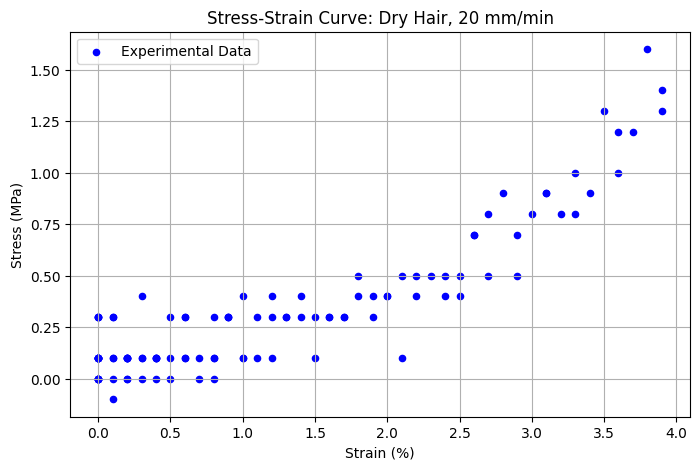

In [42]:
plt.figure(figsize=(8, 5)) #Raw stress-strain data
plt.scatter(df["Strain (%)"], df["Stress (MPa)"], s=20, label = "Experimental Data", color='blue')

plt.xlabel("Strain (%)")
plt.ylabel("Stress (MPa)")
plt.title("Stress-Strain Curve: Dry Hair, 20 mm/min")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
mean_df = (df.groupby("Strain (%)")["Stress (MPa)"].agg(['mean', 'std']).reset_index())
print(mean_df)

    Strain (%)      mean       std
0          0.0  0.105263  0.112909
1          0.1  0.116667  0.160208
2          0.2  0.071429  0.048795
3          0.3  0.150000  0.173205
4          0.4  0.080000  0.044721
5          0.5  0.133333  0.152753
6          0.6  0.200000  0.115470
7          0.7  0.050000  0.070711
8          0.8  0.125000  0.125831
9          0.9  0.300000  0.000000
10         1.0  0.200000  0.173205
11         1.1  0.200000  0.141421
12         1.2  0.266667  0.152753
13         1.3  0.300000  0.000000
14         1.4  0.350000  0.070711
15         1.5  0.200000  0.141421
16         1.6  0.300000  0.000000
17         1.7  0.300000  0.000000
18         1.8  0.450000  0.070711
19         1.9  0.350000  0.070711
20         2.0  0.400000  0.000000
21         2.1  0.300000  0.282843
22         2.2  0.450000  0.070711
23         2.3  0.500000       NaN
24         2.4  0.450000  0.070711
25         2.5  0.450000  0.070711
26         2.6  0.700000  0.000000
27         2.7  0.65

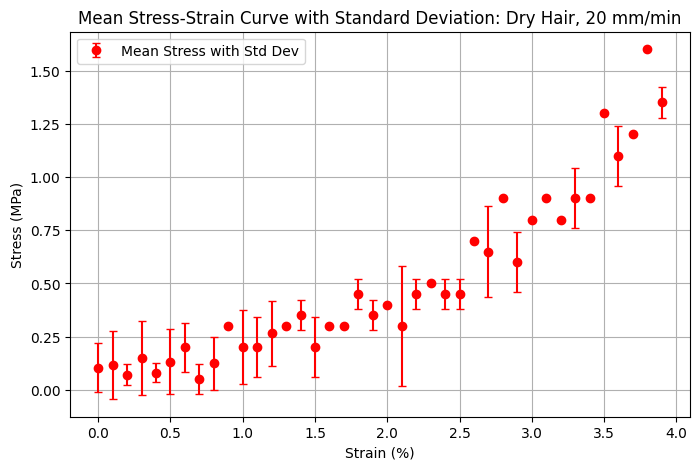

In [44]:
plt.figure(figsize=(8, 5)) 
plt.errorbar(mean_df["Strain (%)"], mean_df["mean"], yerr=mean_df["std"], fmt='o', label='Mean Stress with Std Dev', color='red', capsize=3)

plt.xlabel("Strain (%)")
plt.ylabel("Stress (MPa)")
plt.title("Mean Stress-Strain Curve with Standard Deviation: Dry Hair, 20 mm/min")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
strain = mean_df["Strain (%)"].values
stress = mean_df["mean"].values

#Define the exponential model
def exponential(x, A, B):
    return A * (np.exp(B * x) - 1)

# 3. Set minimum number of points
# ==========================================

MIN_POINTS_TOE = 16
MIN_POINTS_ELASTIC = 16

# 4. Define possible breakpoints
# ==========================================

# Only search between these strain values
min_breakpoint = 0.01
max_breakpoint = 3.9

possible_breakpoints = np.linspace(
    min_breakpoint,
    max_breakpoint,
    100
)

#5. Store results
# ==========================================

results = []


# 6. Test every possible breakpoint
# ==========================================

for breakpoint in possible_breakpoints:

    # -----------------------------
    # Divide data
    # -----------------------------

    toe_mask = strain <= breakpoint
    elastic_mask = strain > breakpoint

    toe_strain = strain[toe_mask]
    toe_stress = stress[toe_mask]

    elastic_strain = strain[elastic_mask]
    elastic_stress = stress[elastic_mask]


    # -----------------------------
    # Minimum point requirement
    # -----------------------------

    if len(toe_strain) < MIN_POINTS_TOE:
        continue

    if len(elastic_strain) < MIN_POINTS_ELASTIC:
        continue


    # ==========================================
    # 7. Fit exponential to toe region
    # ==========================================

    try:

        popt_exp, _ = curve_fit(
            exponential,
            toe_strain,
            toe_stress,
            p0=[1, 1],
            maxfev=10000
        )

    except RuntimeError:

        continue


    A, B = popt_exp


    # Predicted toe stresses

    predicted_toe = exponential(
        toe_strain,
        A,
        B
    )


    # ==========================================
    # 8. Fit linear elastic region
    # ==========================================

    linear_coefficients = np.polyfit(
        elastic_strain,
        elastic_stress,
        1
    )

    E = linear_coefficients[0]
    C = linear_coefficients[1]


    # Predicted elastic stresses

    predicted_elastic = (
        E * elastic_strain + C
    )


    # ==========================================
    # 9. Calculate MSE
    # ==========================================

    toe_mse = np.mean(
        (toe_stress - predicted_toe) ** 2
    )

    elastic_mse = np.mean(
        (elastic_stress - predicted_elastic) ** 2
    )


    # ==========================================
    # 10. Combined MSE
    # ==========================================

    total_mse = toe_mse + elastic_mse


    # ==========================================
    # 11. Store results
    # ==========================================

    results.append({
        "breakpoint": breakpoint,
        "toe_mse": toe_mse,
        "elastic_mse": elastic_mse,
        "total_mse": total_mse,
        "A": A,
        "B": B,
        "E": E,
        "C": C,
        "n_toe": len(toe_strain),
        "n_elastic": len(elastic_strain)
    })


#12. Convert results to DataFrame
# ==========================================

results_df = pd.DataFrame(results)


# ==========================================
# 13. Find best breakpoint
# ==========================================

best_index = results_df["total_mse"].idxmin()

best_result = results_df.loc[best_index]


print("\nBEST BREAKPOINT")
print("----------------------")

print(
    "Breakpoint strain:",
    best_result["breakpoint"]
)

print(
    "Toe MSE:",
    best_result["toe_mse"]
)

print(
    "Elastic MSE:",
    best_result["elastic_mse"]
)

print(
    "Total MSE:",
    best_result["total_mse"]
)

print(
    "Number of toe points:",
    int(best_result["n_toe"])
)

print(
    "Number of elastic points:",
    int(best_result["n_elastic"])
)

print("\nToe exponential parameters")

print(
    "A =",
    best_result["A"]
)

print(
    "B =",
    best_result["B"]
)

print("\nElastic linear parameters")

print(
    "E =",
    best_result["E"]
)

print(
    "C =",
    best_result["C"]
)



BEST BREAKPOINT
----------------------
Breakpoint strain: 2.0139393939393937
Toe MSE: 0.004223101846421682
Elastic MSE: 0.015210295475530936
Total MSE: 0.01943339732195262
Number of toe points: 21
Number of elastic points: 19

Toe exponential parameters
A = 1148.745272557871
B = 0.0001783124353269784

Elastic linear parameters
E = 0.5850877192982455
C = -0.9210526315789469


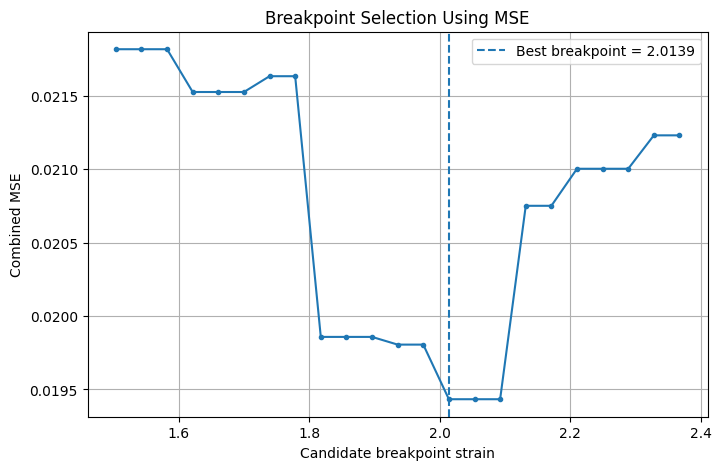

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["breakpoint"],
    results_df["total_mse"],
    marker="o",
    markersize=3
)

plt.axvline(
    best_result["breakpoint"],
    linestyle="--",
    label=f'Best breakpoint = {best_result["breakpoint"]:.4f}'
)

plt.xlabel("Candidate breakpoint strain")
plt.ylabel("Combined MSE")
plt.title("Breakpoint Selection Using MSE")

plt.legend()
plt.grid(True)

plt.show()



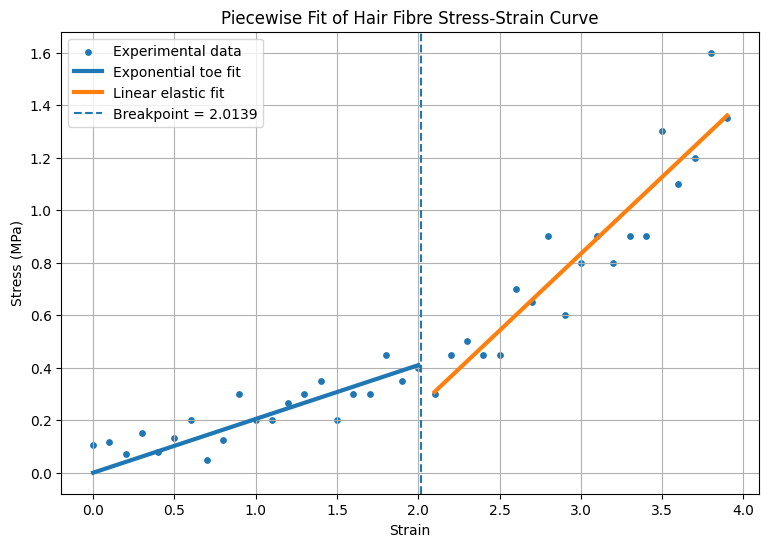

In [47]:
best_breakpoint = best_result["breakpoint"]

toe_mask = strain <= best_breakpoint
elastic_mask = strain > best_breakpoint

toe_strain = strain[toe_mask]
toe_stress = stress[toe_mask]

elastic_strain = strain[elastic_mask]
elastic_stress = stress[elastic_mask]


# Exponential fit

A = best_result["A"]
B = best_result["B"]

toe_x = np.linspace(
    toe_strain.min(),
    toe_strain.max(),
    200
)

toe_y = exponential(
    toe_x,
    A,
    B
)


# Linear fit

E = best_result["E"]
C = best_result["C"]

elastic_x = np.linspace(
    elastic_strain.min(),
    elastic_strain.max(),
    200
)

elastic_y = E * elastic_x + C


# Plot

plt.figure(figsize=(9, 6))

plt.scatter(
    strain,
    stress,
    s=15,
    label="Experimental data"
)

plt.plot(
    toe_x,
    toe_y,
    linewidth=3,
    label="Exponential toe fit"
)

plt.plot(
    elastic_x,
    elastic_y,
    linewidth=3,
    label="Linear elastic fit"
)

plt.axvline(
    best_breakpoint,
    linestyle="--",
    label=f"Breakpoint = {best_breakpoint:.4f}"
)

plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Piecewise Fit of Hair Fibre Stress-Strain Curve")

plt.legend()
plt.grid(True)

plt.show()